# Demande électrique des data centers (IA & crypto)

Analyse de la croissance de la demande électrique des data centers (IA générative et cryptomonnaies) et comparaison au total mondial de production d'électricité (scénario courant).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

root = Path('../data/preproc')
dc = pd.read_excel(root / 'data_center_electricity_demand_TWh.xlsx')
world = pd.read_excel(root / 'world_total_electricity_generation.xlsx')

# Nettoyage: on garde historique + scénario CURRENT
world = world.drop_duplicates(subset=['Year', 'Scenario'])
world_current = world[world['Scenario'].str.upper().str.contains('HISTORICAL|CURRENT')]

merged = dc.merge(world_current[['Year', 'Total_generation_TWh', 'Scenario']], on='Year', how='left')
merged['Part_total_%'] = merged['Total'] / merged['Total_generation_TWh'] * 100
merged.head()


,Year,Part hors IA,Part IA générative,Part cryptomonnaies,Total,Total_generation_TWh,Scenario,Part_total_%
0,2023,340,40,150,530,29975.0,Historical,1.768140
1,2024,367,58,174,599,31229.0,Historical,1.918089
2,2024,367,58,174,599,31229.0,CURRENT,1.918089
3,2025,397,84,201,682,NaN,NaN,NaN
4,2026,428,122,233,783,NaN,NaN,NaN


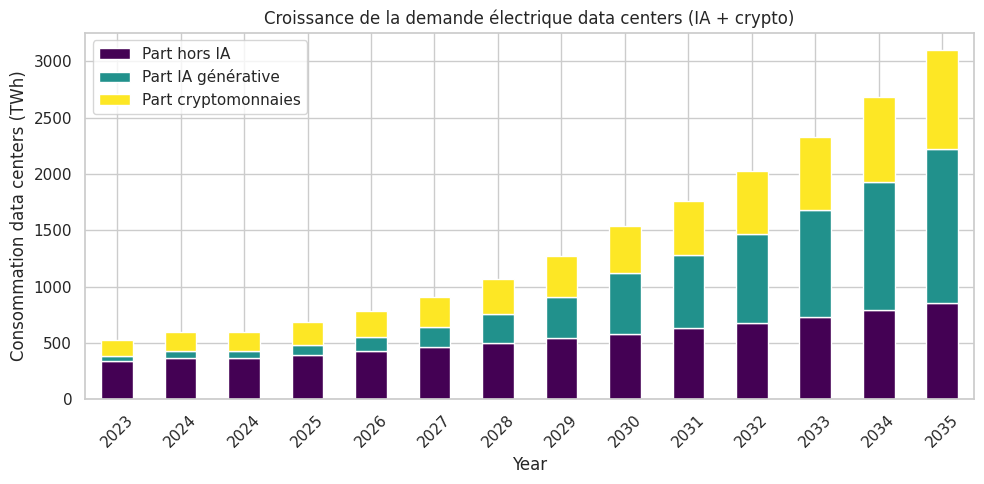

In [2]:
# Empilement des composantes de demande data centers
components = ['Part hors IA', 'Part IA générative', 'Part cryptomonnaies']
ax = merged.set_index('Year')[components].plot(kind='bar', stacked=True, colormap='viridis')
ax.set_ylabel('Consommation data centers (TWh)')
ax.set_title('Croissance de la demande électrique data centers (IA + crypto)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


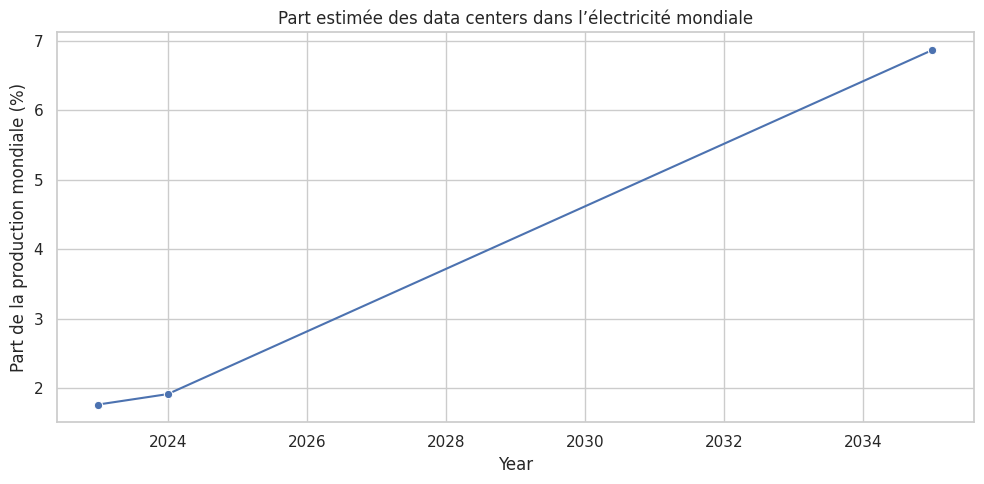

In [3]:
# Part des data centers dans la production mondiale
ax = sns.lineplot(data=merged, x='Year', y='Part_total_%', marker='o')
ax.set_ylabel('Part de la production mondiale (%)')
ax.set_title('Part estimée des data centers dans l’électricité mondiale')
plt.tight_layout()
plt.show()


## Lecture rapide
- La consommation des data centers (IA générative + crypto) croît fortement sur 2023-2027 et dépasse rapidement la partie non-IA.
- Leur part dans la production mondiale passe déjà à plusieurs % dès le milieu de la décennie (estimation grossière), ce qui exerce une pression sur le système électrique.
- Cela justifie de tester la résilience du mix et d’anticiper l’effacement/efficacité côté IA.


## Analyse complémentaire : parts %, CAGR et intensité carbone
- Parts IA/crypto/hors-IA vs production mondiale (scénarios historical/current/stated/netzero si joint).
- Seuils: années où la part data centers dépasse 2%, 5%, 10%.
- CAGR 2023→2027/2030 de la demande data centers.
- Ordres de grandeur CO₂ avec deux intensités (0,35 et 0,1 kg/kWh).


In [4]:
import numpy as np

# Parts % vs production mondiale (si world_current dispo)
parts = []
for _, row in merged.iterrows():
    if pd.notna(row.get('Total_generation_TWh')):
        pct = row['Total']/row['Total_generation_TWh']*100
        parts.append({'Year':row['Year'],'Part_%':pct})
parts_df = pd.DataFrame(parts)
parts_df


,Year,Part_%
0,2023,1.768140
1,2024,1.918089
2,2024,1.918089
3,2035,6.867809


In [5]:
# Seuils 2%, 5%, 10%
for thr in [2,5,10]:
    hit = parts_df[parts_df['Part_%']>=thr].sort_values('Year').head(1)
    if not hit.empty:
        print(f"Seuil {thr}% atteint en {int(hit.iloc[0]['Year'])}")
    else:
        print(f"Seuil {thr}% non atteint dans les données")


Seuil 2% atteint en 2035
Seuil 5% atteint en 2035
Seuil 10% non atteint dans les données


In [6]:
# CAGR 2023->2027 et 2023->2030
for target in [2027,2030]:
    base = dc.loc[dc['Year']==2023,'Total'].values
    tgt = dc.loc[dc['Year']==target,'Total'].values if target in dc['Year'].values else []
    if len(base)>0 and len(tgt)>0 and base[0]>0:
        cagr = (tgt[0]/base[0])**(1/(target-2023)) - 1
        print(f"CAGR 2023->{target}: {cagr*100:.1f}% par an")


CAGR 2023->2027: 14.5% par an
CAGR 2023->2030: 16.5% par an


In [7]:
# Estimation CO2 (intensités 0.35 et 0.1 kg/kWh)
INTS = [0.35, 0.1]
co2_est = []
for _, row in dc.iterrows():
    for inten in INTS:
        mt = row['Total']*1e9*inten/1e6
        co2_est.append({'Year':row['Year'],'Intensity_kg_per_kWh':inten,'MtCO2_equiv':mt})
pd.DataFrame(co2_est)


,Year,Intensity_kg_per_kWh,MtCO2_equiv
0,2023,0.35,185500.0
1,2023,0.10,53000.0
2,2024,0.35,209650.0
3,2024,0.10,59900.0
4,2025,0.35,238700.0
5,2025,0.10,68200.0
6,2026,0.35,274050.0
7,2026,0.10,78300.0
8,2027,0.35,318500.0
9,2027,0.10,91000.0
